# COCO Caption Classification with Zero-shot and Few-shot Learning

This notebook focuses on Multimodal Classification using the COCO dataset. It evaluates the ability to align visual semantics with complex linguistic context.

## Setup and Configurations

In [1]:
import sys
import os

REPO_NAME = 'Coco_caption_classification'
REPO_PATH = os.path.join('/content', REPO_NAME)
NOTEBOOKS_DIR = os.path.join(REPO_PATH, 'notebooks')

# Clone the repository if it doesn't exist
if not os.path.exists(REPO_PATH):
    print(f"Cloning repository {REPO_NAME}...")
    !git clone https://github.com/ThaiLearnCoding/{REPO_NAME}.git {REPO_PATH}

# Change working directory to notebooks/ if it's not already there
if os.getcwd() != NOTEBOOKS_DIR:
    os.chdir(NOTEBOOKS_DIR)

print("Working directory:", os.getcwd())

# Add the repository root to sys.path if not already present
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

import torch
import yaml
import wandb

# Config
config_path = '../settings/config.yaml'
try:
    with open(config_path, 'r') as f:
         config = yaml.safe_load(f)
except FileNotFoundError:
    print("Config file not found, using generic defaults")
    config = {
        "training": {
            "k_shots": [8, 16, 32],
            "device": "cuda" if torch.cuda.is_available() else "cpu",
            "epochs": 20
        },
        "models": {"clip_vit": "ViT-B/32", "clip_rn50": "RN50"}
    }

# Enable or disable training
TRAIN_MODEL = True # Set to False if you just want to run inference

device = config['training']['device'] if 'training' in config else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Cloning repository Coco_caption_classification...
Cloning into '/content/Coco_caption_classification'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 51 (delta 16), reused 47 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 1.24 MiB | 5.68 MiB/s, done.
Resolving deltas: 100% (16/16), done.
Working directory: /content/Coco_caption_classification/notebooks
Using device: cuda


In [2]:
# System dependencies
!pip install -r ../settings/requirements.txt
!pip install wandb -qU

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-install-to6rb450/clip_4b74585ec6c84c9992e599536f3ad690
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-install-to6rb450/clip_4b74585ec6c84c9992e599536f3ad690
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=06d5fac6f4cca4de4f2c115d2bcb258c4b2f5fbc17b73557860bb29f9a376cbb
  Stored in directory: /tmp/pip-ephem-wheel-cache-fl4puvls/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## Dataset Retrieval and Loading

We load the MS COCO multimodal subset from `coco_subset_images/coco_multimodal_subset.json`

In [3]:
# 1. Ensure gdown is ready
!pip install --upgrade gdown

import os
import gdown
import json

# --- CONFIGURATION (Absolute paths for stability) ---
ROOT = '/content/Coco_caption_classification'
IMAGE_DIR = os.path.join(ROOT, 'coco_subset_images/images')
JSON_DIR = os.path.join(ROOT, 'coco_subset_images')
JSON_PATH = os.path.join(JSON_DIR, 'coco_multimodal_subset.json')
ZIP_PATH = '/content/coco_data.zip'

ZIP_FILE_ID = '1ZZ6NBl5567WZVRTCNspteJ_IiZeRr352'
JSON_FILE_ID = '1-WsEVMu4Ubxr-rV6LvgxhMh2Voe3HZwU'
# ---------------------

# 1. Create the final destination folder
os.makedirs(IMAGE_DIR, exist_ok=True)

# 2. Download the 2GB Archive
if not os.path.exists(ZIP_PATH):
    print("Downloading Image Archive...")
    gdown.download(f'https://drive.google.com/uc?id={ZIP_FILE_ID}', ZIP_PATH, quiet=False)

# 3. Extract directly to IMAGE_DIR using the -j flag
# -j: junk paths (do not make directories)
# -q: quiet mode
# -d: destination directory
if not os.listdir(IMAGE_DIR):
    print("Extracting images directly into target folder (ignoring zip internal paths)...")
    !unzip -q -j {ZIP_PATH} -d {IMAGE_DIR}
    print("Extraction complete.")

# 4. Download the JSON metadata to the parent folder
if not os.path.exists(JSON_PATH):
    print("Downloading JSON metadata...")
    gdown.download(f'https://drive.google.com/uc?id={JSON_FILE_ID}', JSON_PATH, quiet=False)

# 5. Load and Verify
with open(JSON_PATH, 'r') as f:
    final_dataset = json.load(f)

print(f"\n✅ SUCCESS!")
print(f"Images count: {len(os.listdir(IMAGE_DIR))}")
print(f"Images location: {IMAGE_DIR}")
print(f"JSON location: {JSON_PATH}")

Downloading...
From (original): https://drive.google.com/uc?id=1ZZ6NBl5567WZVRTCNspteJ_IiZeRr352
From (redirected): https://drive.google.com/uc?id=1ZZ6NBl5567WZVRTCNspteJ_IiZeRr352&confirm=t&uuid=d825af42-47bd-4e2a-858d-da10be01fb5c
To: /content/coco_data.zip
100%|██████████| 685M/685M [00:03<00:00, 173MB/s]


Extracting images directly into target folder (ignoring zip internal paths)...
Extraction complete.

✅ SUCCESS!
Images count: 11952
Images location: /content/Coco_caption_classification/coco_subset_images/images
JSON location: /content/Coco_caption_classification/coco_subset_images/coco_multimodal_subset.json


In [4]:
from src import data_loader, model_arch, utils

# Inherit the dataset loaded in the Setup cell
try:
    subset_data = final_dataset
    print(f"Loaded {len(subset_data)} samples.")
except NameError:
    print("final_dataset is not defined. Make sure you run the prior dataset downloading cell first.")
    subset_data = []

Loaded 11960 samples.


In [5]:
final_dataset[0]

{'image_id': 15391,
 'image_url': 'http://images.cocodataset.org/train2017/000000015391.jpg',
 'true_label': 'bear',
 'choices': ['A brown horse standing next to a white truck.',
  'A grey cat is laying on a filled suitcase.',
  'A row of elephants, including one baby, walk down a dirt pathway.',
  'A charging bear running down a dirt path.',
  'A bi-plane with a wing walker on its wings.'],
 'ground_truth_idx': 3}

## Exploratory Data Analysis (EDA)

Here we visualize the class distribution using plotly and show a random 3x3 grid of images along with their ground-truth caption (green) and distractor captions (red).

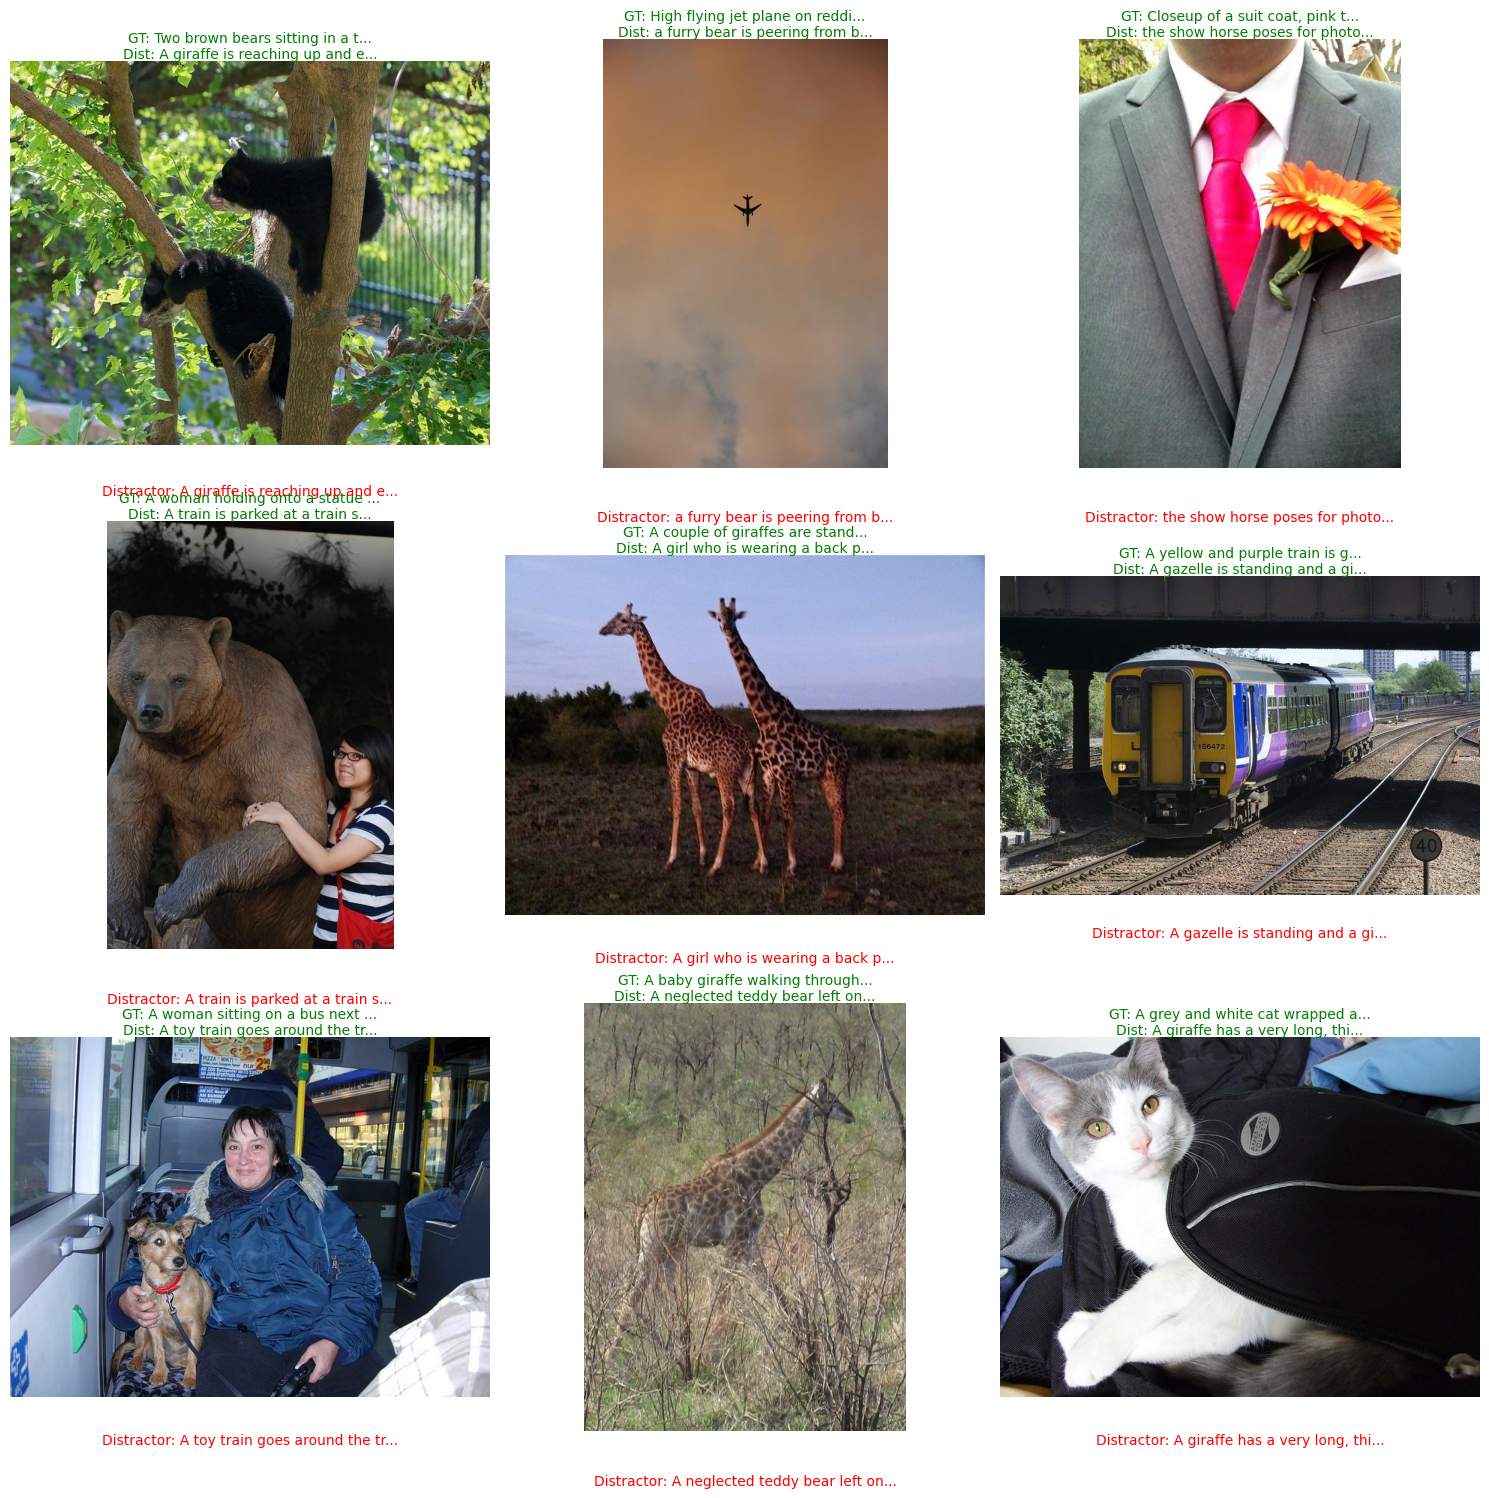

In [6]:
import plotly.express as px
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

if subset_data:
    # Plotly bar chart
    counts = Counter([item['true_label'] for item in subset_data])
    df = pd.DataFrame(counts.items(), columns=['Category', 'Count']).sort_values('Count', ascending=False)

    fig = px.bar(df, x='Category', y='Count', title='Data Distribution per Category (COCO Subset)',
                 color='Category', template='plotly_white')
    fig.show()

    # 3x3 Grid visualization
    fig_grid, axes = plt.subplots(3, 3, figsize=(15, 15))
    samples = random.sample(subset_data, 9)
    # Reference the global variable for extraction path defined in cell 1 setup
    image_dir = IMAGE_DIR if 'IMAGE_DIR' in locals() else '../coco_subset_images/images'

    for i, ax in enumerate(axes.flat):
        sample = samples[i]

        # In the downloaded JSON, image ID doesn't have '.jpg' attached natively inside the key. Let's form it properly.
        image_id = sample['image_id']
        img_path = os.path.join(image_dir, f"{image_id}.jpg")

        try:
            img = Image.open(img_path)
            ax.imshow(img)
            ax.axis('off')

            # Ground truth in green, 1 distractor in red for visualization (to keep it readable)
            gt_index = sample['ground_truth_idx']
            choices = sample['choices']
            gt = choices[gt_index]

            distractors = [c for idx, c in enumerate(choices) if idx != gt_index]
            distractor = distractors[0] if distractors else "No distractor"

            text = f"GT: {gt[:30]}...\nDist: {distractor[:30]}..."
            ax.set_title(text, fontsize=10, color='green', pad=2)

            # Highlight distractor part
            ax.text(0.5, -0.1, f"Distractor: {distractor[:30]}...", ha='center', va='top', transform=ax.transAxes, color='red', fontsize=10)
        except Exception as e:
            ax.set_title("Image missing")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Few-Shot Data Splitting

We isolate 32 training samples per class and remove them from the evaluation subset. We extract subsets for $k=8$, $k=16$, and $k=32$.

In [7]:
train_max_data, eval_data = data_loader.create_few_shot_splits(subset_data, n_max_shots=32, seed=42)

print(f"Max train pool size: {len(train_max_data)}")
print(f"Evaluation set size: {len(eval_data)}")

Max train pool size: 320
Evaluation set size: 11640


## Model Architecture and Initialization

Load the CLIP variants (`ViT-B/32` and `RN50`). Here we prepare DataLoaders that apply the architecture-specific normalization depending on the chosen model. We then set up the Model with Custom Classification Head (Linear Probing).

In [ ]:
import clip

clip_model_name_vit = config['models']['clip_vit']
clip_model_name_rn50 = config['models']['clip_rn50']

print("Initializing ViT-B/32 Zero-Shot Model")
vit_zs_model = model_arch.CLIPZeroShotClassifier(model_name=clip_model_name_vit, device=device)
preprocess_vit = vit_zs_model.preprocess

print("Initializing RN50 Zero-Shot Model")
rn50_zs_model = model_arch.CLIPZeroShotClassifier(model_name=clip_model_name_rn50, device=device)
preprocess_rn50 = rn50_zs_model.preprocess

print("Initializing linear probe models for fine-tuning")
# Residual Dual Probe mapping to similarity score with Cross-Entropy Loss
vit_lp_model = model_arch.ResidualDualProbeClassifier(model_name=clip_model_name_vit, device=device, n_captions=5)
rn50_lp_model = model_arch.ResidualDualProbeClassifier(model_name=clip_model_name_rn50, device=device, n_captions=5)

# Size & param counts
print("\nViT Size Info:")
vit_params, vit_train_params, vit_size_mb = utils.calculate_model_size_params(vit_lp_model)

print("\nRN50 Size Info:")
rn50_params, rn50_train_params, rn50_size_mb = utils.calculate_model_size_params(rn50_lp_model)

Initializing ViT-B/32 Zero-Shot Model


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 110MiB/s]


Initializing RN50 Zero-Shot Model


100%|████████████████████████████████████████| 244M/244M [00:01<00:00, 210MiB/s]


Initializing linear probe models for fine-tuning

ViT Size Info:
Total Parameters: 151,277,315
Trainable Parameters: 2
Model size: 337.063MB

RN50 Size Info:
Total Parameters: 102,007,139
Trainable Parameters: 2
Model size: 243.438MB


## Linear Probing Training with Weights & Biases

We implement the training loop running the linear layer optimization for different $k$-shot values. The model uses Cross Entropy on similarity scores to identify the correct prompt.

In [ ]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import time
import os
import copy

def train_linear_probe(model, model_name, preprocess, k, num_epochs=10, num_patient=3):
    image_dir = IMAGE_DIR if 'IMAGE_DIR' in locals() else '../coco_subset_images/images'
    k_train_loader, k_test_loader = data_loader.create_dataloaders(
        train_max_data, eval_data, image_dir,
        preprocess, batch_size=config['training'].get('batch_size', 32), k=k
    )

    # Re-initialize the residual gates for fresh training
    model.img_gate = nn.Linear(model.dim, model.dim).to(device)
    model.txt_gate = nn.Linear(model.dim, model.dim).to(device)
    nn.init.zeros_(model.img_gate.weight)
    nn.init.zeros_(model.img_gate.bias)
    nn.init.zeros_(model.txt_gate.weight)
    nn.init.zeros_(model.txt_gate.bias)

    optimizer = optim.Adam(
        list(model.img_gate.parameters()) + list(model.txt_gate.parameters()), 
        lr=config['training'].get('learning_rate', 0.001)
    )
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_model_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        pbar = tqdm(k_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in pbar:
            images, text_candidates, targets, _, _ = batch
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(images, text_candidates)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == targets).sum().item()

            if epoch == 0 and total == 0: # First batch of first epoch
              print(f"DEBUG: Target values: {preds[:5]}")
              print(f"DEBUG: Target values: {targets[:5]}")
              print(f"DEBUG: Logits shape: {logits.shape}")

            total += targets.size(0)

            pbar.set_postfix({'loss': loss.item()})

        train_acc = correct / total

        # Evaluate
        eval_acc, eval_f1 = utils.evaluate_model(model, k_test_loader, device)

        print(f"Epoch {epoch+1} - Loss: {total_loss/len(k_train_loader):.4f} - Train Acc: {train_acc:.4f} - Eval Acc: {eval_acc:.4f} - Eval F1: {eval_f1:.4f}")

        wandb.log({
            f"{model_name}_{k}shot_train_loss": total_loss/len(k_train_loader),
            f"{model_name}_{k}shot_train_acc": train_acc,
            f"{model_name}_{k}shot_eval_acc": eval_acc,
            f"{model_name}_{k}shot_eval_f1": eval_f1
        })

        if eval_acc > best_acc:
            best_acc = eval_acc
            best_model_state = {
                'img_gate': copy.deepcopy(model.img_gate.state_dict()),
                'txt_gate': copy.deepcopy(model.txt_gate.state_dict())
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= num_patient:
                print(f"Early stopping triggered after {num_patient} epochs without improvement.")
                break

    # Load best and save to file/artifact
    if best_model_state is not None:
        model.img_gate.load_state_dict(best_model_state['img_gate'])
        model.txt_gate.load_state_dict(best_model_state['txt_gate'])

    if not os.path.exists('../models'):
        os.makedirs('../models')
    save_path = f"../models/best_{model_name}_{k}shot.pth"
    if best_model_state is not None:
        torch.save(best_model_state, save_path)

        artifact = wandb.Artifact(f"{model_name}_{k}shot_model", type="model")
        artifact.add_file(save_path)
        wandb.log_artifact(artifact)

    return best_acc, eval_f1

k_shots_list = config['training']['k_shots']

if TRAIN_MODEL and subset_data:
    wandb.login()
    wandb.init(project=config['wandb']['project'], entity=config['wandb'].get('entity', None))

    for k in k_shots_list:
        print(f"\n--- Training ViT-B/32 Linear Probe for k={k} ---")
        train_linear_probe(vit_lp_model, "vit_b32", preprocess_vit, k, num_epochs=config['training'].get('epochs', 20))

        print(f"\n--- Training RN50 Linear Probe for k={k} ---")
        train_linear_probe(rn50_lp_model, "rn50", preprocess_rn50, k, num_epochs=config['training'].get('epochs', 20))

    wandb.finish()
else:
    print("Training is disabled (TRAIN_MODEL=False) or no data loaded. Skipping fine-tuning.")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.




--- Training ViT-B/32 Linear Probe for k=8 ---


Epoch 1/20:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

Epoch 1/20:  67%|██████▋   | 2/3 [00:01<00:00,  2.25it/s, loss=1.65]

DEBUG: Target values: tensor([3, 2, 4, 3, 1], device='cuda:0')
DEBUG: Target values: tensor([0, 4, 3, 1, 4], device='cuda:0')
DEBUG: Logits shape: torch.Size([32, 5])


...

Epoch 2 - Loss: 1.6494 - Train Acc: 0.0000 - Eval Acc: 0.0000 - Eval F1: 0.0000


Epoch 3/20:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

Epoch 3/20: 100%|██████████| 3/3 [00:01<00:00,  2.64it/s, loss=1.65]


Epoch 3 - Loss: 1.6487 - Train Acc: 0.0000 - Eval Acc: 0.0000 - Eval F1: 0.0000


Epoch 4/20:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

Epoch 4/20: 100%|██████████| 3/3 [00:01<00:00,  2.71it/s, loss=1.65]


KeyboardInterrupt: 

## Model Evaluation and Metrics Comparison

Evaluate Zero-shot models to compare with Few-shot. Calculate Accuracy, F1 score and Time.

In [17]:
import time

def evaluate_zero_shot(model, preprocess):
    if not subset_data: return 0, 0, 0
    image_dir = IMAGE_DIR if 'IMAGE_DIR' in locals() else '../coco_subset_images/images'
    _, test_loader = data_loader.create_dataloaders(
        train_max_data, eval_data, image_dir,
        preprocess, batch_size=config['training'].get('batch_size', 32), k=8
    )

    start_time = time.time()
    acc, f1 = utils.evaluate_model(model, test_loader, device)
    end_time = time.time()

    inference_time = end_time - start_time
    print(f"Zero-Shot Accuracy: {acc:.4f}")
    print(f"Zero-Shot F1 Score: {f1:.4f}")
    print(f"Inference Time for {len(eval_data)} samples: {inference_time:.4f}s")

    return acc, f1, inference_time

print("\n--- ViT-B/32 Zero-Shot Evaluation ---")
vit_zs_acc, vit_zs_f1, vit_zs_time = evaluate_zero_shot(vit_zs_model, preprocess_vit)

print("\n--- RN50 Zero-Shot Evaluation ---")
rn50_zs_acc, rn50_zs_f1, rn50_zs_time = evaluate_zero_shot(rn50_zs_model, preprocess_rn50)


--- ViT-B/32 Zero-Shot Evaluation ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



Zero-Shot Accuracy: 0.9954
Zero-Shot F1 Score: 0.9954
Inference Time for 11640 samples: 96.0025s

--- RN50 Zero-Shot Evaluation ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



Zero-Shot Accuracy: 0.9953
Zero-Shot F1 Score: 0.9953
Inference Time for 11640 samples: 96.2039s


## Prediction Visualizations and Interpretability

Interpret prediction results using Attention Rollout (Text encoder), GradCam (ResNet Image encoder) and EigenCam (ViT Image encoder) for correct and error classification cases.

In [ ]:
# Install pytorch-grad-cam for prediction visualizations
!pip install grad-cam opencv-python-headless

from src.utils import plot_prediction_visualizations

# Plot visualization using the utility function designed for this
if 'subset_data' in locals():
    # Use IMAGE_DIR if available, else default to relative path
    img_dir = IMAGE_DIR if 'IMAGE_DIR' in locals() else '../coco_subset_images/images'
    
    plot_prediction_visualizations(
        subset_data=subset_data,
        vit_zs_model=vit_zs_model,
        rn50_zs_model=rn50_zs_model,
        preprocess_vit=preprocess_vit,
        preprocess_rn50=preprocess_rn50,
        device=device,
        image_dir=img_dir
    )
else:
    print("Data not available for visualization.")